# ana_W: Full Flow with SVD and EVD

This notebook runs one fixed-parameter flow and compares two matrix views of the lifted observable dynamics:

- SVD: singular values and the left/right singular-vector matrices `U` and `V^T`.
- EVD: sorted eigenvalues, sorted right eigenvectors `Q`, and the non-orthogonality diagnostic `Q^TQ - I`.

The main matrix is

$$
A_o=
\begin{pmatrix}
\lambda & 0 & 0 \\
0 & \mu & \lambda^2-\mu \\
0 & 0 & \lambda^2
\end{pmatrix}.
$$

## 1. Imports and shared settings

Topic: import the tools, keep the observable fixed, and set one plot style.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

REPO_ROOT = None
for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (candidate / 'tools.py').exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError('Could not locate repository root containing tools.py')
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from tools import (
    make_step_system_matrix,
    step_map,
    observable_step,
    simulate_discrete_system,
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 140

STATE_NAMES = ['x', 'y']
OBS_NAMES = ['x', 'y', 'x^2']
HEATMAP_CMAP = 'vlag'
POSITIVE_CMAP = 'Blues'

FULL_CONFIG = {
    'lam': 0.3,
    'mu': 1,
    'steps': 40,
    'phase_steps': 22,
    'phase_samples': 18,
    'seed': 7,
    'initial_state': np.array([0.80, -0.35], dtype=float),
}

display(Markdown(
    'Fixed observable: $[x, y] \mapsto [x, y, x^2]$. This notebook does not use any noise term.'
))

Fixed observable: $[x, y] \mapsto [x, y, x^2]$. This notebook does not use any noise term.

## 2. Helper functions

Topic: define helper functions for axis limits, heatmaps, stable SVD/EVD signs, eigenpair sorting, and the final plot layout.

In [2]:
def choose_heatmap_cmap(matrix):
    matrix = np.asarray(matrix, dtype=float)
    if np.any(matrix < 0) and np.any(matrix > 0):
        return HEATMAP_CMAP
    return POSITIVE_CMAP

def canonicalize_svd(U, Vt):
    """Fix the singular-vector signs so the plots stay stable."""
    U = np.array(U, dtype=float, copy=True)
    Vt = np.array(Vt, dtype=float, copy=True)
    for k in range(U.shape[1]):
        pivot = np.argmax(np.abs(U[:, k]))
        sign = 1.0 if U[pivot, k] >= 0 else -1.0
        U[:, k] *= sign
        Vt[k, :] *= sign
    return U, Vt

def as_real_if_close(values, tol=1e-10, name='array'):
    values = np.asarray(values)
    max_imag = np.max(np.abs(np.imag(values))) if np.iscomplexobj(values) else 0.0
    if max_imag > tol:
        raise ValueError(f'{name} has a non-negligible imaginary part: {max_imag:.3e}')
    return np.real(values)

def canonicalize_eigenvectors(Q):
    """Fix each eigenvector sign by making its largest-magnitude entry positive."""
    Q = np.array(Q, dtype=float, copy=True)
    for k in range(Q.shape[1]):
        pivot = np.argmax(np.abs(Q[:, k]))
        sign = 1.0 if Q[pivot, k] >= 0 else -1.0
        Q[:, k] *= sign
    return Q

def sorted_eigendecomposition(A):
    eigvals, eigvecs = np.linalg.eig(A)
    eigvals = as_real_if_close(eigvals, name='eigenvalues')
    eigvecs = as_real_if_close(eigvecs, name='eigenvectors')
    order = np.lexsort((-eigvals, -np.abs(eigvals)))
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    eigvecs = canonicalize_eigenvectors(eigvecs)
    return eigvals, eigvecs

def auto_axis_limits(points, pad_ratio=0.08):
    points = np.asarray(points, dtype=float)
    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    spans = np.maximum(maxs - mins, 1e-6)
    pad = spans * pad_ratio
    return (mins[0] - pad[0], maxs[0] + pad[0]), (mins[1] - pad[1], maxs[1] + pad[1])

def draw_heatmap(ax, matrix, row_labels, col_labels, title, annot_fmt='.3f', center=None):
    matrix = np.asarray(matrix, dtype=float)
    cmap = choose_heatmap_cmap(matrix)
    heat_center = center if cmap == HEATMAP_CMAP else None
    sns.heatmap(
        matrix,
        ax=ax,
        cmap=cmap,
        annot=True,
        fmt=annot_fmt,
        cbar=True,
        square=matrix.shape[0] == matrix.shape[1],
        xticklabels=col_labels,
        yticklabels=row_labels,
        center=heat_center,
        linewidths=0.5,
        linecolor='white',
    )
    ax.set_title(title)

def simulate_phase_bundle(lam, mu, steps, n_samples=20, seed=0):
    rng = np.random.default_rng(seed)
    initial_states = np.column_stack([
        rng.uniform(-0.95, 0.95, n_samples),
        rng.uniform(-0.95, 0.95, n_samples),
    ])
    pack = simulate_discrete_system(
        step_map,
        initial_states,
        steps=steps,
        system_kwargs={'lam': lam, 'mu': mu},
        dt=1.0,
    )
    return pack['trajectories']

def plot_full_flow_grid(A, xy, obs, U, s, Vt, eigvals, eigvecs, eigvec_orth_gap, lam, mu, phase_bundle):
    all_points = np.asarray(phase_bundle, dtype=float).reshape(-1, 2)
    xlim, ylim = auto_axis_limits(all_points)
    eig_labels = [r'$q_1$', r'$q_2$', r'$q_3$']

    fig, axes = plt.subplots(3, 3, figsize=(15, 13.2))

    draw_heatmap(axes[0, 0], A, OBS_NAMES, OBS_NAMES, '$A_o$', center=0.0)

    for traj in phase_bundle:
        axes[0, 1].plot(traj[:, 0], traj[:, 1], color='0.75', linewidth=0.9, alpha=0.9)
    axes[0, 1].plot(xy[:, 0], xy[:, 1], color='tab:orange', linewidth=2.0, label='representative trajectory')
    axes[0, 1].scatter(xy[0, 0], xy[0, 1], color='tab:green', s=28, label='start')
    axes[0, 1].scatter(xy[-1, 0], xy[-1, 1], color='tab:red', s=28, label='end')
    axes[0, 1].set_title('Phase portrait')
    axes[0, 1].set_xlabel('x')
    axes[0, 1].set_ylabel('y')
    axes[0, 1].set_xlim(xlim)
    axes[0, 1].set_ylim(ylim)
    axes[0, 1].legend(loc='best', fontsize=8)

    for idx, name in enumerate(OBS_NAMES):
        axes[0, 2].plot(np.arange(len(obs)), obs[:, idx], linewidth=2.0, label=name)
    axes[0, 2].set_title('Lifted observable trajectories')
    axes[0, 2].set_xlabel('step')
    axes[0, 2].set_ylabel('value')
    axes[0, 2].legend(loc='best', fontsize=8)

    draw_heatmap(axes[1, 0], U, OBS_NAMES, [r'$u_1$', r'$u_2$', r'$u_3$'], 'Left singular-vector matrix $U$', center=0.0)

    axes[1, 1].bar(np.arange(1, len(s) + 1), s, color='tab:blue', alpha=0.85)
    axes[1, 1].plot(np.arange(1, len(s) + 1), s, color='0.35', linewidth=1.1)
    axes[1, 1].set_title('Singular value spectrum')
    axes[1, 1].set_xlabel('index')
    axes[1, 1].set_ylabel('singular value')

    draw_heatmap(axes[1, 2], Vt, [r'$v_1^T$', r'$v_2^T$', r'$v_3^T$'], OBS_NAMES, 'Right singular-vector matrix $V^T$', center=0.0)

    draw_heatmap(axes[2, 0], eigvec_orth_gap, eig_labels, eig_labels, 'Eigenvector non-orthogonality $Q^TQ-I$', center=0.0)

    eig_index = np.arange(1, len(eigvals) + 1)
    axes[2, 1].bar(eig_index, eigvals, color='tab:green', alpha=0.85)
    axes[2, 1].plot(eig_index, eigvals, color='0.35', linewidth=1.1)
    axes[2, 1].axhline(0.0, color='0.35', linewidth=0.9)
    axes[2, 1].set_title('Eigenvalues sorted by $|\\lambda|$')
    axes[2, 1].set_xlabel('index')
    axes[2, 1].set_ylabel('eigenvalue')
    axes[2, 1].set_xticks(eig_index)

    draw_heatmap(axes[2, 2], eigvecs, OBS_NAMES, eig_labels, 'Right eigenvector matrix $Q$', center=0.0)

    fig.suptitle(f'$\\lambda$={lam}, $\\mu$={mu}', fontsize=15, y=1.01)
    fig.tight_layout()
    plt.show()

## 3. Step 1. Build the full-flow data

Topic: in one step, choose `lam, mu`, simulate the state trajectory, build the phase-portrait bundle, lift the data, build $A_o$, apply SVD and EVD, and compute compact diagnostics for both decompositions.

The output below is printed in a compact and readable way.


In [3]:
rep_pack = simulate_discrete_system(
    step_map,
    FULL_CONFIG['initial_state'],
    steps=FULL_CONFIG['steps'],
    system_kwargs={'lam': FULL_CONFIG['lam'], 'mu': FULL_CONFIG['mu']},
    dt=1.0,
)
xy = rep_pack['trajectories'][0]

phase_bundle = simulate_phase_bundle(
    FULL_CONFIG['lam'],
    FULL_CONFIG['mu'],
    steps=FULL_CONFIG['phase_steps'],
    n_samples=FULL_CONFIG['phase_samples'],
    seed=FULL_CONFIG['seed'],
)

obs = observable_step(xy, mode='default')
A = make_step_system_matrix(FULL_CONFIG['lam'], FULL_CONFIG['mu'])

U, s, Vt = np.linalg.svd(A, full_matrices=True)
U, Vt = canonicalize_svd(U, Vt)
uv_gap_fro = np.linalg.norm(U - Vt.T, ord='fro')

eigvals, eigvecs = sorted_eigendecomposition(A)
eigvec_orth_gap = eigvecs.T @ eigvecs - np.eye(eigvecs.shape[1])
eigvec_nonorth_fro = np.linalg.norm(eigvec_orth_gap, ord='fro')

all_points = np.asarray(phase_bundle, dtype=float).reshape(-1, 2)
xlim, ylim = auto_axis_limits(all_points)

print('Full-flow setup')
print(f"  lam = {FULL_CONFIG['lam']:.3f}")
print(f"  mu  = {FULL_CONFIG['mu']:.3f}")
print(f"  observable = [x, y, x^2]")
print(f"  main trajectory shape = {xy.shape}")
print(f"  phase bundle shape    = {phase_bundle.shape}")
print(f"  observable shape      = {obs.shape}")
print(f"  auto x range          = ({xlim[0]:.3f}, {xlim[1]:.3f})")
print(f"  auto y range          = ({ylim[0]:.3f}, {ylim[1]:.3f})")
print('')

print('Matrix A_o')
display(pd.DataFrame(A, index=OBS_NAMES, columns=OBS_NAMES))

print('Singular values')
display(pd.DataFrame({'singular_value': s}, index=['s1', 's2', 's3']))

print('U and V difference')
display(pd.DataFrame([
    {
        'fro_gap_between_U_and_V': uv_gap_fro,
    }
]))

print('Eigenvalues sorted by magnitude')
display(pd.DataFrame(
    {
        'eigenvalue': eigvals,
        'abs_eigenvalue': np.abs(eigvals),
    },
    index=[f'lambda_{idx}' for idx in range(1, len(eigvals) + 1)],
))

print('Eigenvector non-orthogonality')
display(pd.DataFrame([
    {
        'fro_norm_of_QTQ_minus_I': eigvec_nonorth_fro,
    }
]))

Full-flow setup
  lam = 0.300
  mu  = 1.000
  observable = [x, y, x^2]
  main trajectory shape = (41, 2)
  phase bundle shape    = (18, 23, 2)
  observable shape      = (41, 3)
  auto x range          = (-1.091, 1.092)
  auto y range          = (-1.981, 1.145)

Matrix A_o


,x,y,x^2
x,0.3,0.0,0.00
y,0.0,1.0,-0.91
x^2,0.0,0.0,0.09


Singular values


,singular_value
s1,1.353432
s2,0.300000
s3,0.066498


U and V difference


,fro_gap_between_U_and_V
0,0.964067


Eigenvalues sorted by magnitude


,eigenvalue,abs_eigenvalue
lambda_1,1.00,1.00
lambda_2,0.30,0.30
lambda_3,0.09,0.09


Eigenvector non-orthogonality


,fro_norm_of_QTQ_minus_I
0,1.0


## 4. Step 2. Full-flow figure

Topic: show the whole full flow in one `3x3` figure.

Top row: `A_o`, phase portrait, lifted observable trajectories.
Middle row: `U`, singular values, `V^T`.
Bottom row: `Q^TQ - I`, sorted eigenvalues, sorted right eigenvectors `Q`.


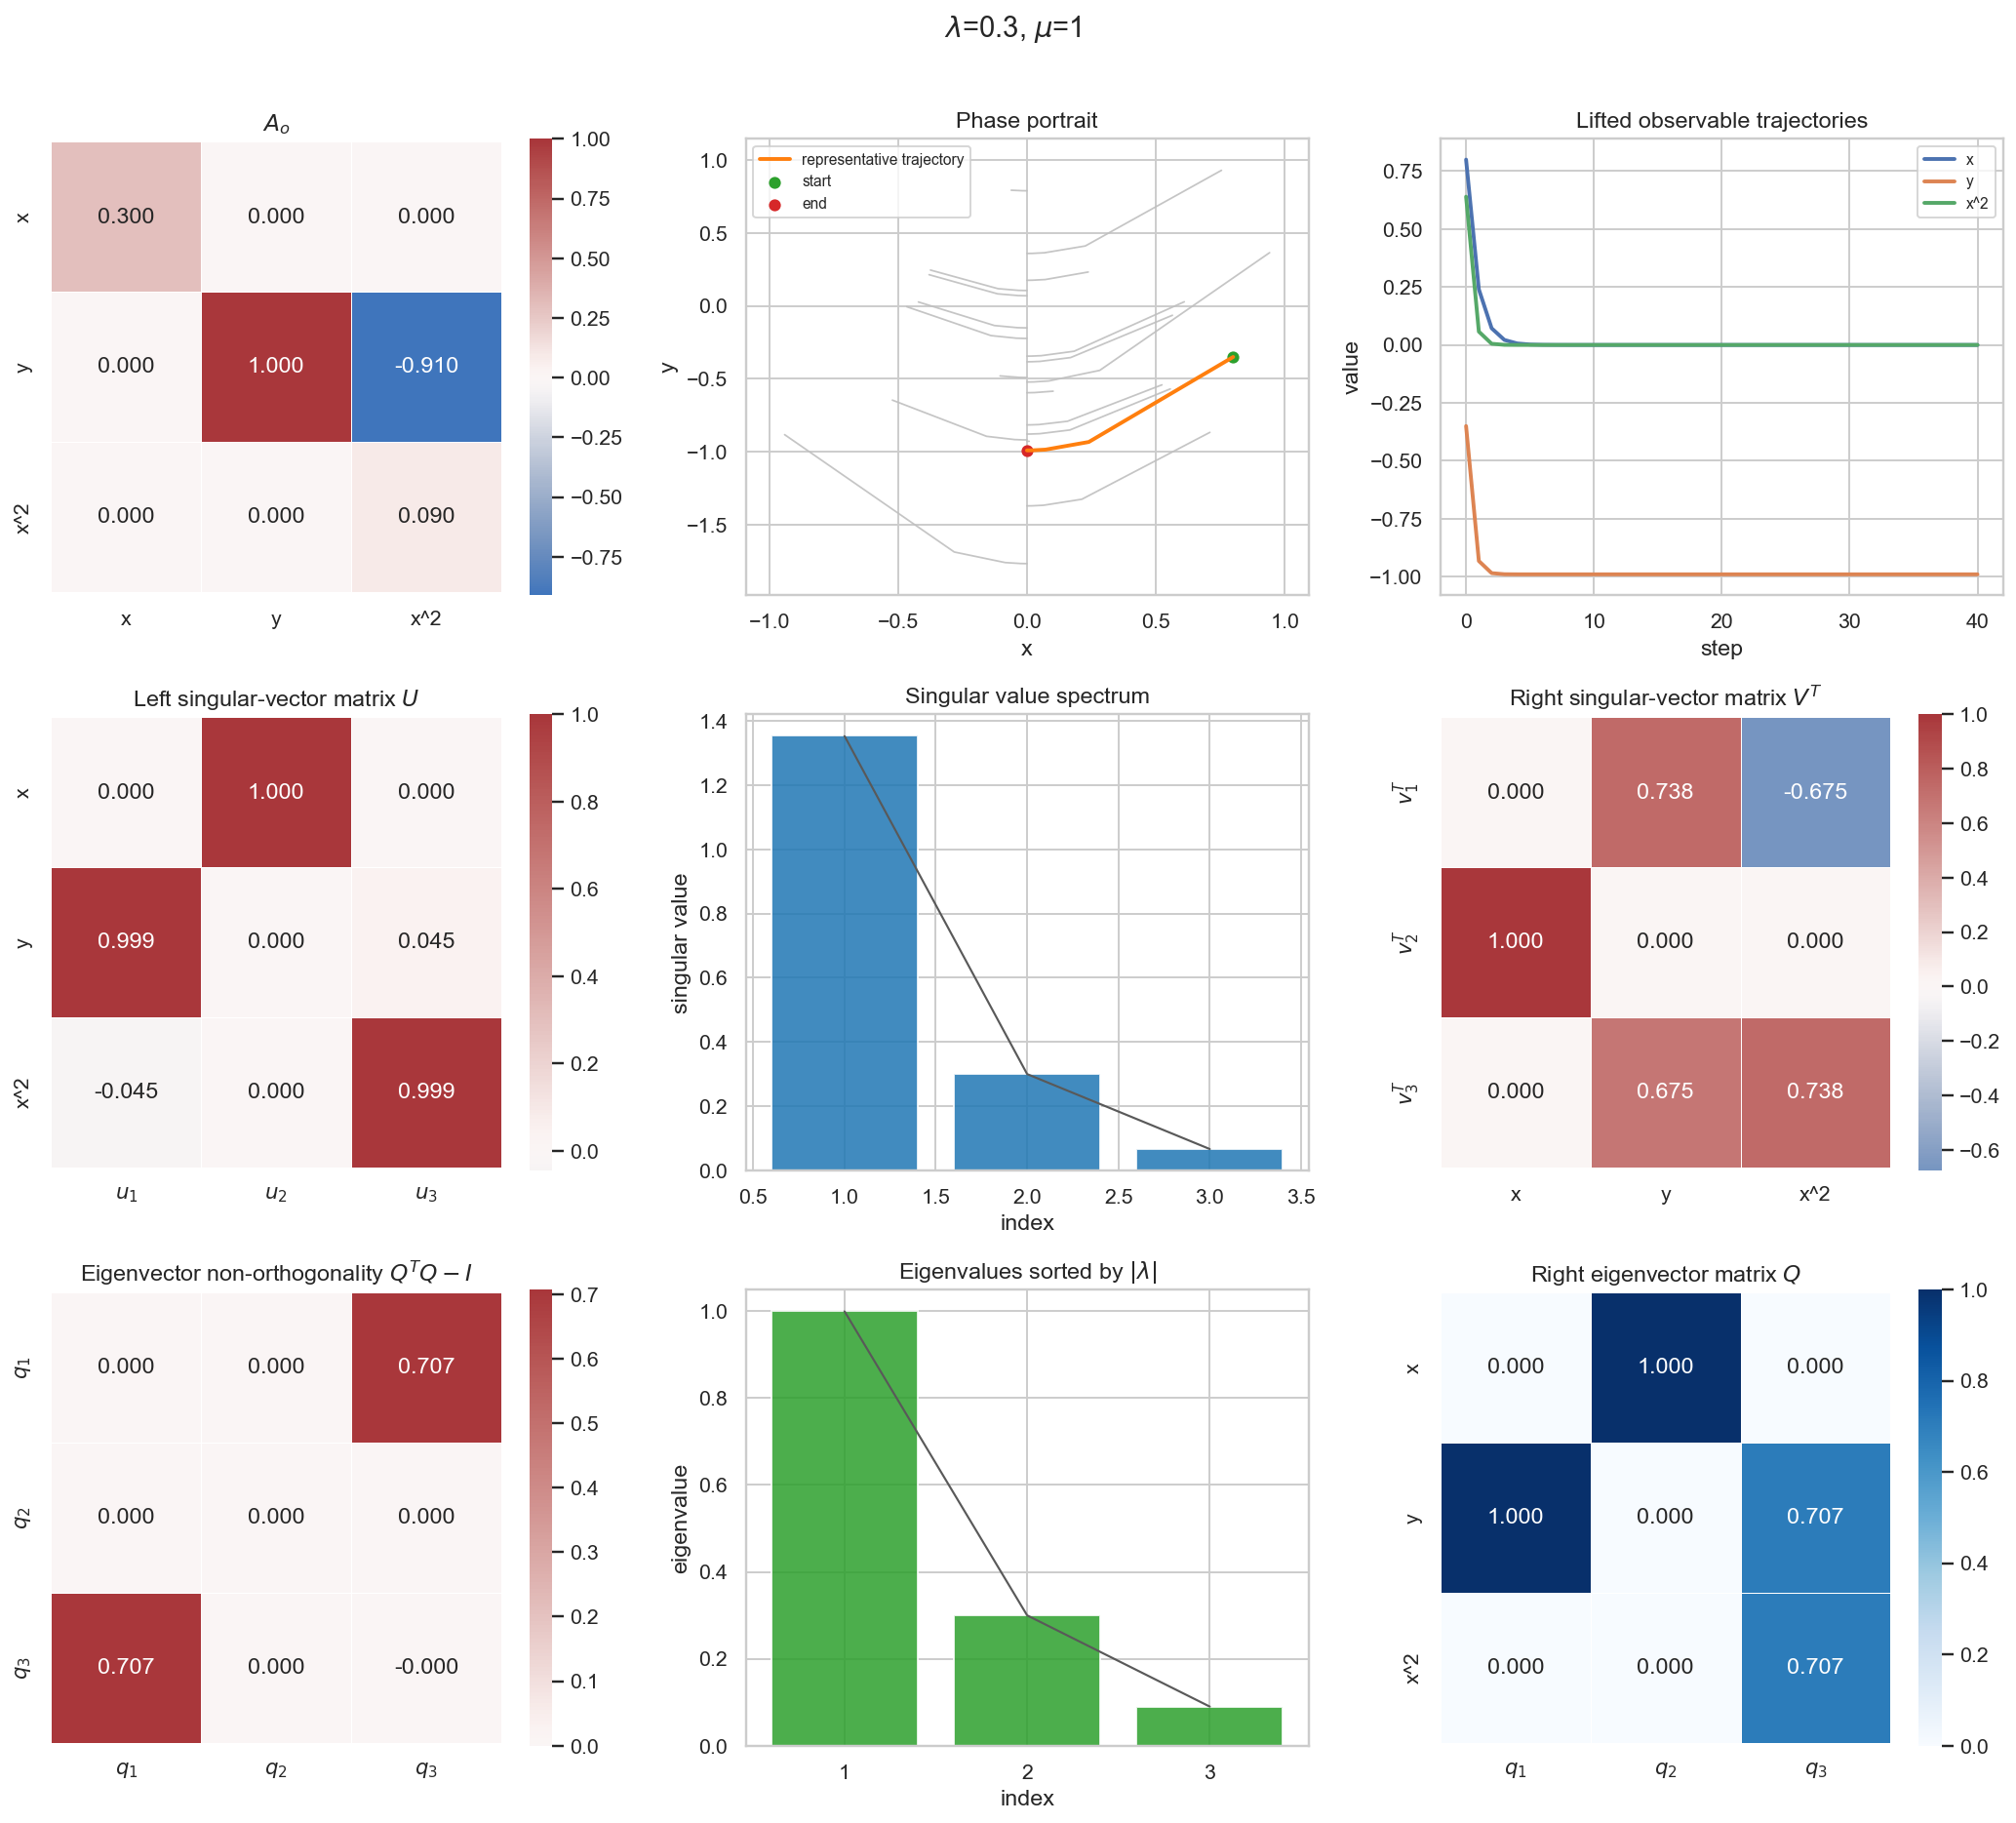

In [4]:
plot_full_flow_grid(
    A=A,
    xy=xy,
    obs=obs,
    U=U,
    s=s,
    Vt=Vt,
    eigvals=eigvals,
    eigvecs=eigvecs,
    eigvec_orth_gap=eigvec_orth_gap,
    lam=FULL_CONFIG['lam'],
    mu=FULL_CONFIG['mu'],
    phase_bundle=phase_bundle,
)

## 5. Step 3. Full-flow summary table

Topic: collect the main SVD and EVD numbers from the single-parameter run.


In [5]:
summary_df = pd.DataFrame([
    {
        'lam': FULL_CONFIG['lam'],
        'mu': FULL_CONFIG['mu'],
        'observable_mode': '[x, y, x^2]',
        'sigma_1': s[0],
        'sigma_2': s[1],
        'sigma_3': s[2],
        'eig_1': eigvals[0],
        'eig_2': eigvals[1],
        'eig_3': eigvals[2],
        'fro_gap_between_U_and_V': uv_gap_fro,
        'fro_norm_of_QTQ_minus_I': eigvec_nonorth_fro,
    }
])
summary_df


,lam,mu,observable_mode,sigma_1,sigma_2,sigma_3,eig_1,eig_2,eig_3,fro_gap_between_U_and_V,fro_norm_of_QTQ_minus_I
0,0.3,1,"[x, y, x^2]",1.353432,0.3,0.066498,1.0,0.3,0.09,0.964067,1.0


## 6. Step2 Flow with SVD and EVD

Topic: repeat the same full-flow analysis for the `step2` system from `ana_ref`, using a clean trajectory and the lifted observable $[x, y, y^2]$.

The system is

$$
x_{k+1}=a x_k + c y_k^2,\qquad y_{k+1}=a y_k.
$$

The lifted observable matrix is

$$
A_{step2}=
\begin{pmatrix}
a & 0 & c \\
0 & a & 0 \\
0 & 0 & a^2
\end{pmatrix}.
$$


In [6]:
from tools import observable_step2

STEP2_OBS_NAMES = ['x', 'y', 'y^2']

STEP2_CONFIG = {
    'a': 0.8,
    'coupling': 10.0,
    'steps': 220,
    'phase_steps': 120,
    'phase_samples': 60,
    'phase_seed': 42,
    'initial_state': np.array([0.20, 0.45], dtype=float),
}

def step2_map(x, y, a=0.8, coupling=10.0):
    x_next = a * x + coupling * (y ** 2)
    y_next = a * y
    return x_next, y_next

def make_step2_system_matrix(a, coupling):
    return np.array(
        [
            [a, 0.0, coupling],
            [0.0, a, 0.0],
            [0.0, 0.0, a ** 2],
        ],
        dtype=float,
    )

def simulate_step2_phase_bundle(a, coupling, steps, n_samples=60, seed=42):
    rng = np.random.default_rng(seed)
    initial_states = np.column_stack([
        rng.uniform(-0.30, 0.30, n_samples),
        rng.uniform(-0.50, 0.50, n_samples),
    ])
    pack = simulate_discrete_system(
        step2_map,
        initial_states,
        steps=steps,
        system_kwargs={'a': a, 'coupling': coupling},
        dt=1.0,
    )
    return pack['trajectories']

def plot_step2_flow_grid(A, xy, obs, U, s, Vt, eigvals, eigvecs, eigvec_orth_gap, a, coupling, phase_bundle):
    all_points = np.vstack([
        np.asarray(phase_bundle, dtype=float).reshape(-1, 2),
        np.asarray(xy, dtype=float),
    ])
    xlim, ylim = auto_axis_limits(all_points, pad_ratio=0.12)
    eig_labels = [r'$q_1$', r'$q_2$', r'$q_3$']

    fig, axes = plt.subplots(3, 3, figsize=(15, 13.2))

    draw_heatmap(axes[0, 0], A, STEP2_OBS_NAMES, STEP2_OBS_NAMES, '$A_{step2}$', center=0.0)

    for traj in phase_bundle:
        axes[0, 1].plot(traj[:, 0], traj[:, 1], color='0.72', linewidth=1.0, alpha=0.9)
    axes[0, 1].plot(xy[:, 0], xy[:, 1], color='tab:orange', linewidth=2.0, label='representative trajectory')
    axes[0, 1].scatter(xy[0, 0], xy[0, 1], color='tab:green', s=28, label='start')
    axes[0, 1].scatter(xy[-1, 0], xy[-1, 1], color='tab:red', s=28, label='end')
    axes[0, 1].set_title('Phase portrait')
    axes[0, 1].set_xlabel('x')
    axes[0, 1].set_ylabel('y')
    axes[0, 1].set_xlim(xlim)
    axes[0, 1].set_ylim(ylim)
    axes[0, 1].legend(loc='best', fontsize=8)

    for idx, name in enumerate(STEP2_OBS_NAMES):
        axes[0, 2].plot(np.arange(len(obs)), obs[:, idx], linewidth=2.0, label=name)
    axes[0, 2].set_title('Lifted observable trajectories')
    axes[0, 2].set_xlabel('step')
    axes[0, 2].set_ylabel('value')
    axes[0, 2].legend(loc='best', fontsize=8)

    draw_heatmap(axes[1, 0], U, STEP2_OBS_NAMES, [r'$u_1$', r'$u_2$', r'$u_3$'], 'Left singular-vector matrix $U$', center=0.0)

    sv_index = np.arange(1, len(s) + 1)
    axes[1, 1].bar(sv_index, s, color='tab:blue', alpha=0.85)
    axes[1, 1].plot(sv_index, s, color='0.35', linewidth=1.1)
    axes[1, 1].set_title('Singular value spectrum')
    axes[1, 1].set_xlabel('index')
    axes[1, 1].set_ylabel('singular value')
    axes[1, 1].set_xticks(sv_index)

    draw_heatmap(axes[1, 2], Vt, [r'$v_1^T$', r'$v_2^T$', r'$v_3^T$'], STEP2_OBS_NAMES, 'Right singular-vector matrix $V^T$', center=0.0)

    draw_heatmap(axes[2, 0], eigvec_orth_gap, eig_labels, eig_labels, 'Eigenvector non-orthogonality $Q^TQ-I$', center=0.0)

    eig_index = np.arange(1, len(eigvals) + 1)
    axes[2, 1].bar(eig_index, eigvals, color='tab:green', alpha=0.85)
    axes[2, 1].plot(eig_index, eigvals, color='0.35', linewidth=1.1)
    axes[2, 1].axhline(0.0, color='0.35', linewidth=0.9)
    axes[2, 1].set_title('Eigenvalues sorted by $|\eta|$')
    axes[2, 1].set_xlabel('index')
    axes[2, 1].set_ylabel('eigenvalue')
    axes[2, 1].set_xticks(eig_index)

    draw_heatmap(axes[2, 2], eigvecs, STEP2_OBS_NAMES, eig_labels, 'Right eigenvector matrix $Q$', center=0.0)

    fig.suptitle(f'step2: $a$={a}, coupling={coupling}', fontsize=15, y=1.01)
    fig.tight_layout()
    plt.show()


## 7. Step2 Data and Decompositions

Topic: build the clean step2 trajectory, lift it to $[x, y, y^2]$, construct the analytic matrix, and compute SVD/EVD diagnostics.


In [7]:
step2_pack = simulate_discrete_system(
    step2_map,
    STEP2_CONFIG['initial_state'],
    steps=STEP2_CONFIG['steps'],
    system_kwargs={'a': STEP2_CONFIG['a'], 'coupling': STEP2_CONFIG['coupling']},
    dt=1.0,
)
step2_xy = step2_pack['trajectories'][0]

step2_phase_bundle = simulate_step2_phase_bundle(
    STEP2_CONFIG['a'],
    STEP2_CONFIG['coupling'],
    steps=STEP2_CONFIG['phase_steps'],
    n_samples=STEP2_CONFIG['phase_samples'],
    seed=STEP2_CONFIG['phase_seed'],
)

step2_obs = observable_step2(step2_xy, mode='default')
A_step2 = make_step2_system_matrix(STEP2_CONFIG['a'], STEP2_CONFIG['coupling'])

U_step2, s_step2, Vt_step2 = np.linalg.svd(A_step2, full_matrices=True)
U_step2, Vt_step2 = canonicalize_svd(U_step2, Vt_step2)
uv_gap_fro_step2 = np.linalg.norm(U_step2 - Vt_step2.T, ord='fro')

eigvals_step2, eigvecs_step2 = sorted_eigendecomposition(A_step2)
eigvec_orth_gap_step2 = eigvecs_step2.T @ eigvecs_step2 - np.eye(eigvecs_step2.shape[1])
eigvec_nonorth_fro_step2 = np.linalg.norm(eigvec_orth_gap_step2, ord='fro')

step2_all_points = np.vstack([
    np.asarray(step2_phase_bundle, dtype=float).reshape(-1, 2),
    step2_xy,
])
step2_xlim, step2_ylim = auto_axis_limits(step2_all_points, pad_ratio=0.12)

print('Step2 setup')
print(f"  a        = {STEP2_CONFIG['a']:.3f}")
print(f"  coupling = {STEP2_CONFIG['coupling']:.3f}")
print(f"  observable = [x, y, y^2]")
print(f"  main trajectory shape = {step2_xy.shape}")
print(f"  phase bundle shape    = {step2_phase_bundle.shape}")
print(f"  observable shape      = {step2_obs.shape}")
print(f"  auto x range          = ({step2_xlim[0]:.3f}, {step2_xlim[1]:.3f})")
print(f"  auto y range          = ({step2_ylim[0]:.3f}, {step2_ylim[1]:.3f})")
print('')

print('Matrix A_step2')
display(pd.DataFrame(A_step2, index=STEP2_OBS_NAMES, columns=STEP2_OBS_NAMES))

print('Singular values')
display(pd.DataFrame({'singular_value': s_step2}, index=['s1', 's2', 's3']))

print('U and V difference')
display(pd.DataFrame([
    {
        'fro_gap_between_U_and_V': uv_gap_fro_step2,
    }
]))

print('Eigenvalues sorted by magnitude')
display(pd.DataFrame(
    {
        'eigenvalue': eigvals_step2,
        'abs_eigenvalue': np.abs(eigvals_step2),
    },
    index=[f'eta_{idx}' for idx in range(1, len(eigvals_step2) + 1)],
))

print('Eigenvector non-orthogonality')
display(pd.DataFrame([
    {
        'fro_norm_of_QTQ_minus_I': eigvec_nonorth_fro_step2,
    }
]))


Step2 setup
  a        = 0.800
  coupling = 10.000
  observable = [x, y, y^2]
  main trajectory shape = (221, 2)
  phase bundle shape    = (60, 121, 2)
  observable shape      = (221, 3)
  auto x range          = (-0.768, 4.116)
  auto y range          = (-0.591, 0.583)

Matrix A_step2


,x,y,y^2
x,0.8,0.0,10.00
y,0.0,0.8,0.00
y^2,0.0,0.0,0.64


Singular values


,singular_value
s1,10.052214
s2,0.800000
s3,0.050934


U and V difference


,fro_gap_between_U_and_V
0,1.851994


Eigenvalues sorted by magnitude


,eigenvalue,abs_eigenvalue
eta_1,0.80,0.80
eta_2,0.80,0.80
eta_3,0.64,0.64


Eigenvector non-orthogonality


,fro_norm_of_QTQ_minus_I
0,1.414033


## 8. Step2 Full-Flow Figure

Topic: show the step2 full flow in one `3x3` figure.

Top row: `A_step2`, phase portrait, lifted observable trajectories.
Middle row: `U`, singular values, `V^T`.
Bottom row: `Q^TQ - I`, sorted eigenvalues, sorted right eigenvectors `Q`.


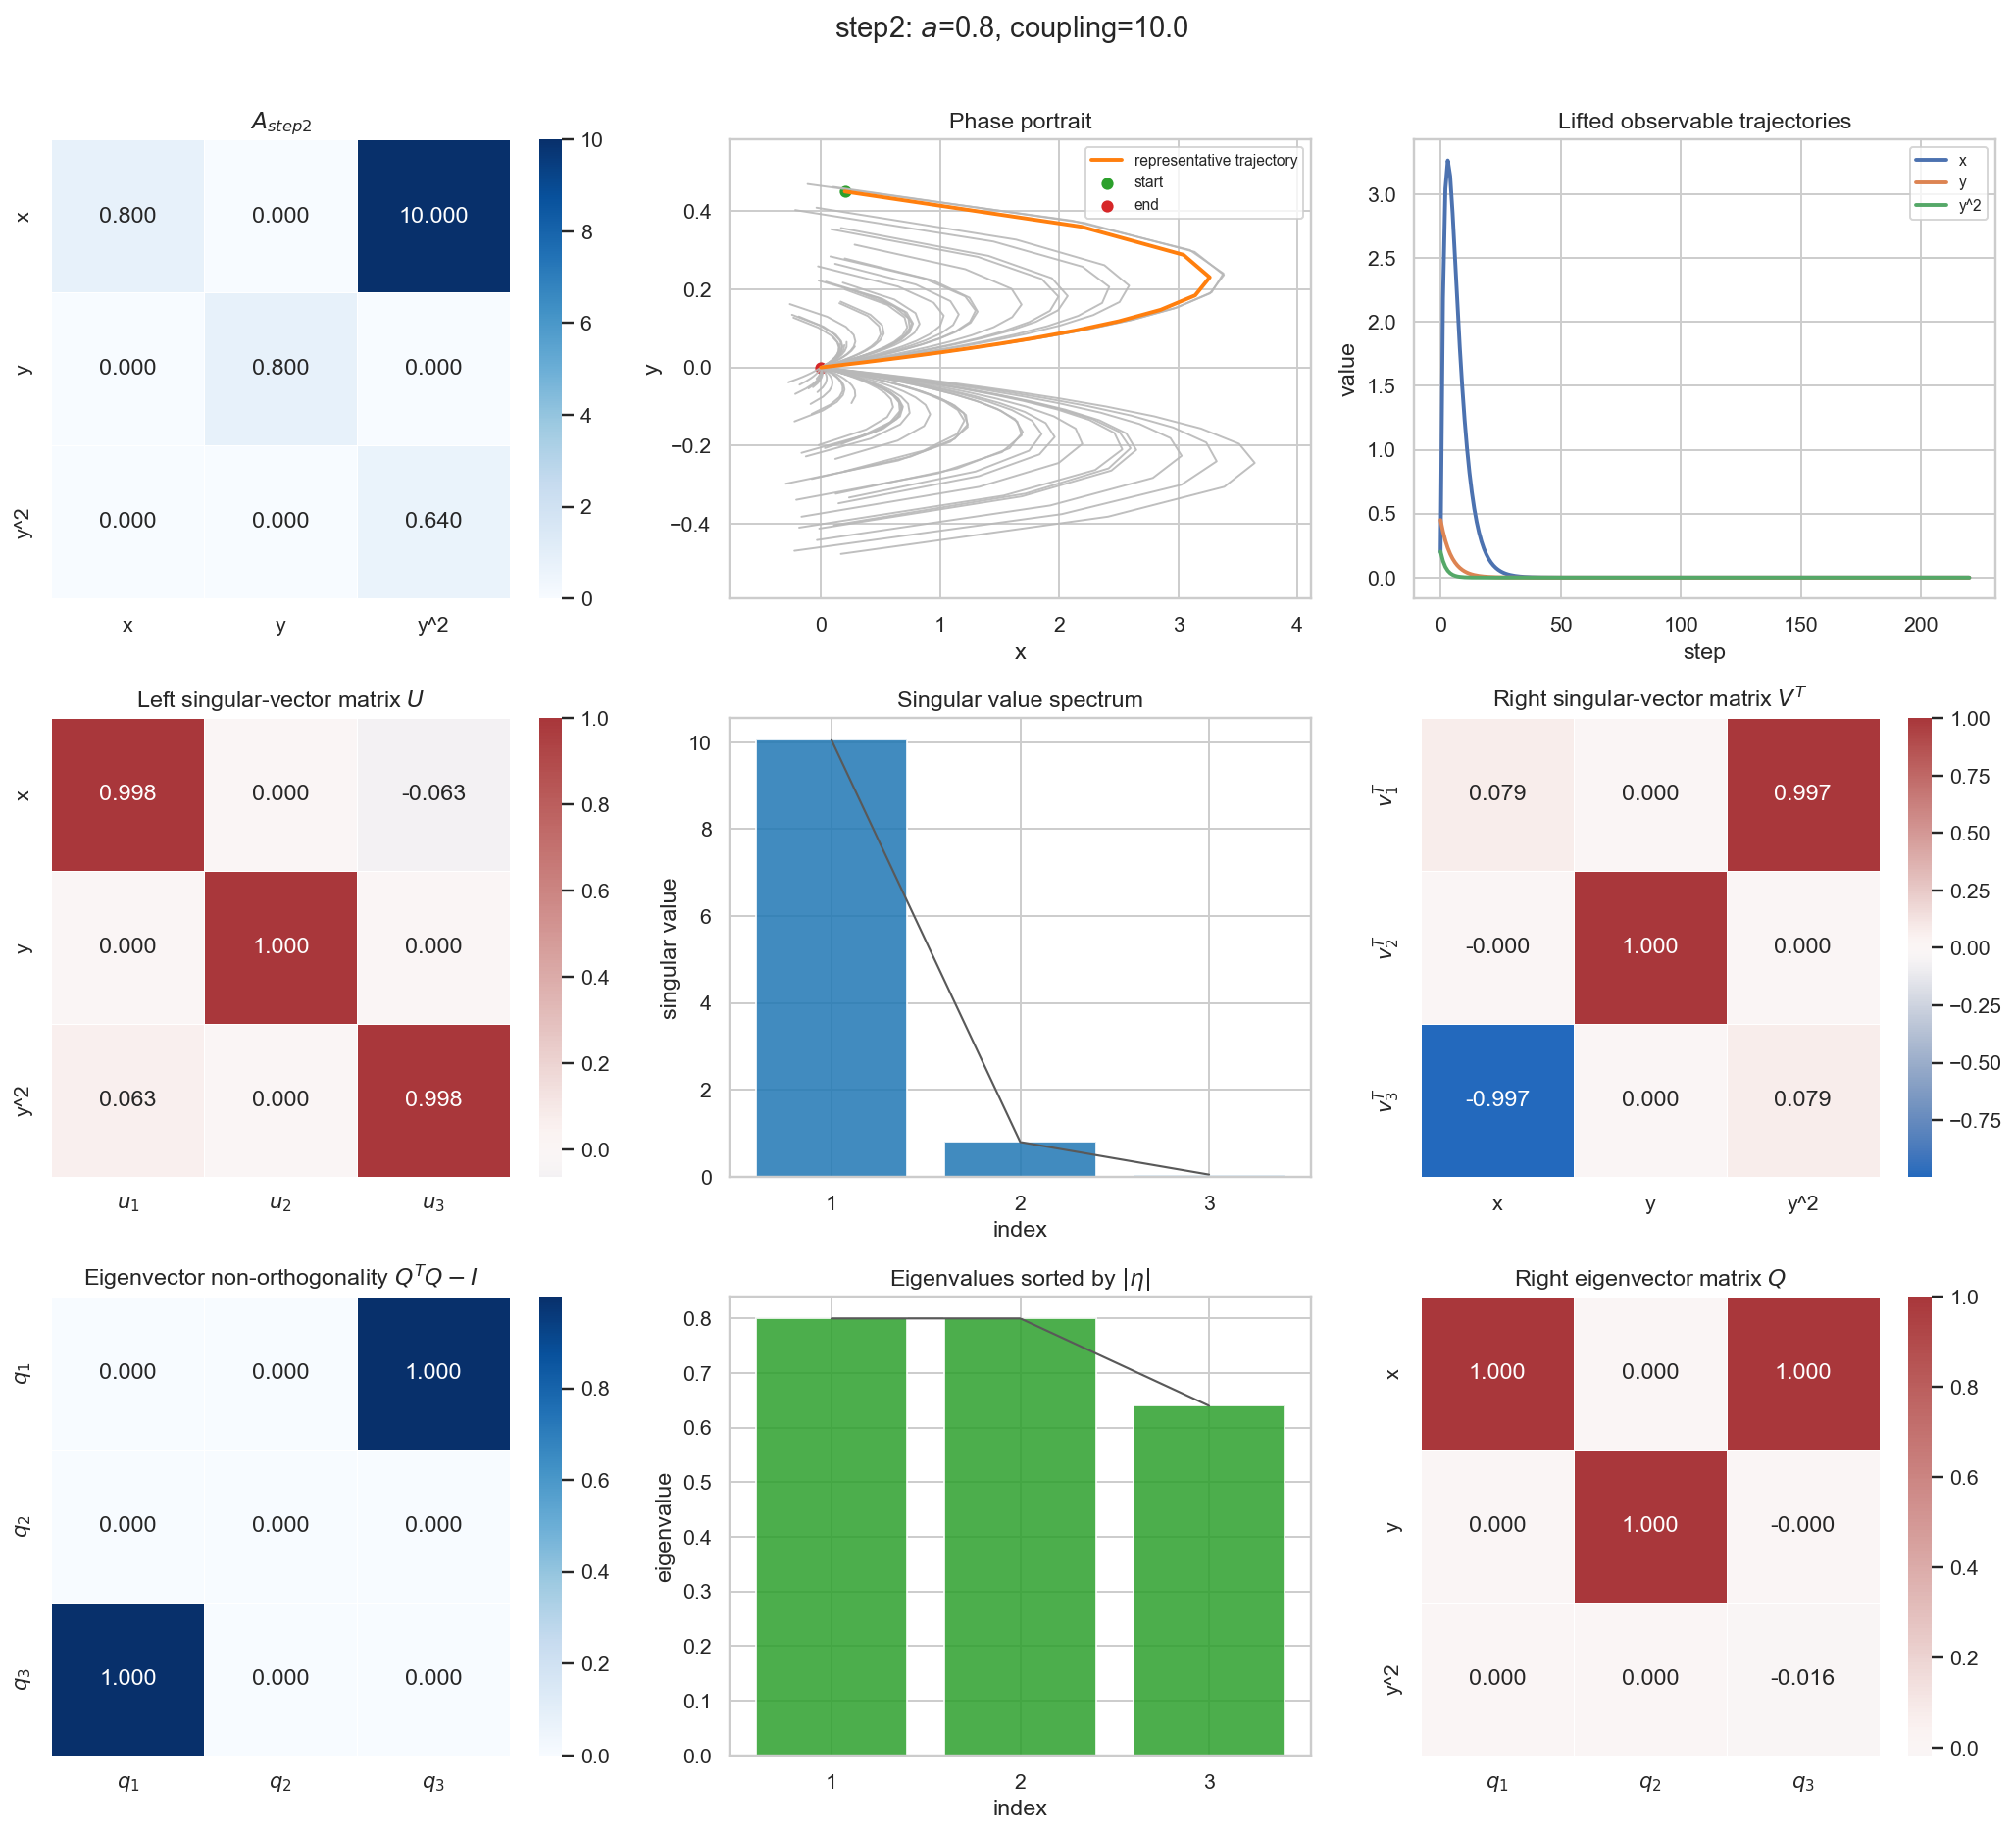

In [8]:
plot_step2_flow_grid(
    A=A_step2,
    xy=step2_xy,
    obs=step2_obs,
    U=U_step2,
    s=s_step2,
    Vt=Vt_step2,
    eigvals=eigvals_step2,
    eigvecs=eigvecs_step2,
    eigvec_orth_gap=eigvec_orth_gap_step2,
    a=STEP2_CONFIG['a'],
    coupling=STEP2_CONFIG['coupling'],
    phase_bundle=step2_phase_bundle,
)


## 9. Step2 Summary Table

Topic: collect the main SVD and EVD numbers from the step2 run.


In [9]:
step2_summary_df = pd.DataFrame([
    {
        'a': STEP2_CONFIG['a'],
        'coupling': STEP2_CONFIG['coupling'],
        'observable_mode': '[x, y, y^2]',
        'sigma_1': s_step2[0],
        'sigma_2': s_step2[1],
        'sigma_3': s_step2[2],
        'eig_1': eigvals_step2[0],
        'eig_2': eigvals_step2[1],
        'eig_3': eigvals_step2[2],
        'fro_gap_between_U_and_V': uv_gap_fro_step2,
        'fro_norm_of_QTQ_minus_I': eigvec_nonorth_fro_step2,
    }
])
step2_summary_df


,a,coupling,observable_mode,sigma_1,sigma_2,sigma_3,eig_1,eig_2,eig_3,fro_gap_between_U_and_V,fro_norm_of_QTQ_minus_I
0,0.8,10.0,"[x, y, y^2]",10.052214,0.8,0.050934,0.8,0.8,0.64,1.851994,1.414033
